In [107]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
from typing import Union
import json
import glob
import yaml

In [108]:
def json_to_dict(json_file_path: Union[str, Path]):
    """
    The function `json_to_dict` reads a JSON file and returns its contents as a
    dictionary.

    Args:
      json_file_path (Union[str, Path]): The `json_file_path` parameter is the
      file path to the JSON
    file that you want to read and convert into a Python dictionary. This
    function reads the JSON data from the specified file and returns it as a
    dictionary.

    Returns:
      The function `json_to_dict` returns a dictionary object containing the
      data loaded from the JSON
    file located at the specified file path.
    """
    with open(json_file_path, "r", encoding="utf-8") as file:
        json_dict = json.load(file)

    file.close()

    return json_dict

In [109]:
def read_config(path_directory: Union[str, Path]):
    """
    The `read_config` function reads a YAML file containing experiment configuration data and
    returns the parsed configuration.

    Returns:
      The function `read_config` returns the experiment configuration data loaded from the
      first YAML file found in the specified directory.
    """
    # yaml_files = glob.glob(str(Path(path_directory, "*.yaml")))
    yaml_data = open(path_directory, "r", encoding="utf-8")
    yaml_config = yaml.safe_load(yaml_data)
    yaml_data.close()

    return yaml_config

### Import Batch Data and Yaml Config File

In [110]:
file_path = Path.cwd() / "data"
folder = "SAM-1000L-B7H4-experiment"
filename_data = "SAM-1000L-B7H4-MasterDataTable.json"
filename_yaml = "SAM-1000L-B7H4.yaml"
full_path_data = file_path / folder / filename_data
full_path_yaml = file_path / folder / filename_yaml

data = json_to_dict(full_path_data)
yaml = read_config(full_path_yaml)
yaml

{'Asset': 'B7H4',
 'Vessel ID': 'FER027',
 'Campaign ID': 'GSK5730912',
 'Lot ID': '57309120M00D00',
 'Batch ID': '5730912101002F',
 'Inoc Date': datetime.date(2025, 11, 21),
 'Last Day': 14,
 'Feed Type': 'B',
 'Tubing Factor': 7.2,
 'Maximum Pump Speed': 190,
 'Bolus Feed Flowrate': 1360,
 'Scale': '1000L',
 'Initial Volumes': {'ambr250': 0.19, '1000L': 740.0, '2000L': 1740.0},
 'Volume Unit': 'L',
 'Feed Unit': 'mL',
 'Master Data File': 'SAM-1000L-B7H4-MasterDataTable.json',
 'Units Dictionary': {'IGG': 'mg/L',
  'LDH': 'mg/L',
  'TCC': 'MM cells/mL',
  'VCC': 'MM cells/mL',
  'VIABILITY': '%',
  'DIAMETER': 'um',
  'OSMOLALITY': 'mOsm/kg',
  'AMMONIUM': 'mM',
  'CALCIUM': 'mg/L',
  'GLUCOSE': 'g/L',
  'GLUTAMINE': 'mM',
  'GLUTAMATE': 'mM',
  'LACTATE': 'g/L',
  'PH': '',
  'PCO2': 'mmHg',
  'PO2': 'mmHg',
  'POTASSIUM': 'mg/L',
  'SODIUM': 'mg/L',
  'BICARBONATE': None,
  'PCO2_AT_TEMP': 'mmHg',
  'PO2_AT_TEMP': 'mmHg',
  'PH_AT_TEMP': '',
  'PH_SETPOINT': '',
  'TEMPERATURE_SETP

In [111]:
folder = r"C:\Users\zah48132\GSK\Biopharm Model Predictive Control - Documents\General\doc\SAM Lab 1000L Batch November 2025"
file = "CTM_data_for_titer_trajectory.csv"
file_path = Path(folder, file)

df = pd.read_csv(file_path)
df_ctm = df.loc[df["Location"]=="B38", :]
grouped = df_ctm.groupby("Day")["titer"].agg(['mean','std'])
df_agg = grouped.reset_index()
df_agg

,Day,mean,std
0,0,21.050000,4.030509
1,1,33.150000,2.616295
2,2,59.550000,10.253048
3,3,120.328571,13.004578
4,4,230.314286,22.308999
5,5,408.971429,35.335332
6,6,708.442857,53.809474
7,7,1046.471429,64.357302
8,8,1491.571429,62.262233
9,9,1845.685714,64.588503


In [128]:
batch_data = np.array([values["titre"] for _, values in data.items()])
cedex_data = np.array([
    v if v is not None else np.nan
    for v in (vals["cedex_titer"] for vals in data.values())
])
titer_setpoint_trajectory = np.array(yaml["Controller"]["Process Variables"]["IGG"]["Data"])[:len(batch_data)]
ctm_avg_trajectory = df_agg["mean"].values[:len(batch_data)]
setpoint_tracking_error = 100*(batch_data-titer_setpoint_trajectory)/titer_setpoint_trajectory
setpoint_tracking_error_cedex = 100*(cedex_data-titer_setpoint_trajectory)/titer_setpoint_trajectory

correction_factor = 0.13
corrected_hplc = cedex_data*(1-correction_factor)
setpoint_tracking_error_cedex_corrected = 100*(corrected_hplc-titer_setpoint_trajectory)/titer_setpoint_trajectory

### Titer Trend

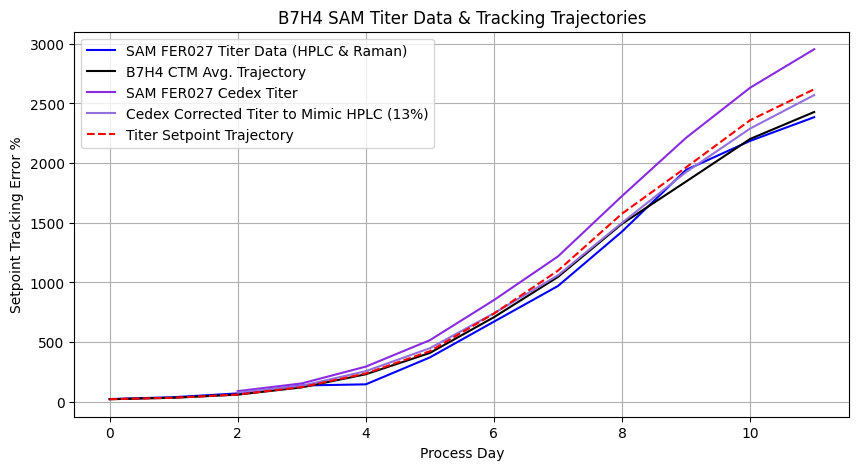

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(0, len(batch_data)),
    batch_data,
    "b-",
    zorder=2,
    label="SAM FER027 Titer Data (HPLC & Raman)",
)
plt.plot(
    np.arange(0, len(batch_data)),
    ctm_avg_trajectory,
    "k",
    zorder=2,
    label="B7H4 CTM Avg. Trajectory",
)
plt.plot(
    np.arange(0, len(batch_data)),
    cedex_data,
    "-",
    c="blueviolet",
    zorder=2,
    label="SAM FER027 Cedex Titer",
)
plt.plot(
    np.arange(0, len(batch_data)),
    corrected_hplc,
    "-",
    c="mediumpurple",
    zorder=2,
    label=f"Cedex Corrected Titer to Mimic HPLC ({correction_factor * 100:0.0f}%)",
)
plt.plot(
    np.arange(0, len(batch_data)),
    titer_setpoint_trajectory,
    "r--",
    zorder=2,
    label="Titer Setpoint Trajectory",
)
plt.xlabel("Process Day")
plt.ylabel("Setpoint Tracking Error %")
plt.title("B7H4 SAM Titer Data & Tracking Trajectories")
plt.grid(zorder=1)
plt.legend()

### Setpoint Tracking Graphs

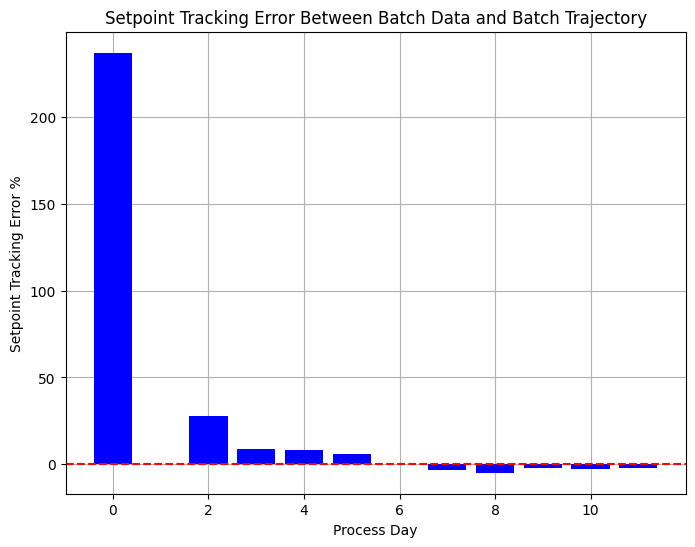

In [129]:
plt.figure(figsize=(8,6))
plt.bar(x=np.arange(0, len(batch_data)), height=setpoint_tracking_error_cedex_corrected, color="b", zorder=2)
plt.axhline(0, linestyle="--", color="r")
plt.xlabel("Process Day")
plt.ylabel("Setpoint Tracking Error %")
plt.title("Setpoint Tracking Error Between Batch Data and Batch Trajectory")
plt.grid(zorder=1)